In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from entsoe import EntsoePandasClient

In [2]:
API_TOKEN = "9af21e20-861e-41a0-873b-03c15cddf7c9"
client = EntsoePandasClient(api_key=API_TOKEN)

In [ ]:
laender = {
    "Deutschland": "DE",
    "Frankreich":  "FR",
    "Spanien":     "ES",
    "Italien":     "IT",
    "Polen":       "PL",
    "Norwegen":    "NO"
    "Kroatien":    "HR"
}

start = pd.Timestamp("2023-01-01", tz="UTC")
end   = pd.Timestamp("2024-01-01", tz="UTC")

SyntaxError: invalid syntax (3731614494.py, line 8)

In [6]:
jahresdaten = {}

for land, kuerzel in laender.items():
    try:
        daten = client.query_load(kuerzel, start=start, end=end)
        gesamt = daten.sum()
        if hasattr(gesamt, 'item'):
            gesamt = gesamt.item()
        jahresdaten[land] = gesamt / 1_000_000
        print(f"{land}: {jahresdaten[land]:.2f} TWh")
    except Exception as e:
        print(f"{land}: Fehler – {e}")

Deutschland: 1833.53 TWh
Frankreich: 425.45 TWh
Spanien: 917.25 TWh
Italien: 276.14 TWh
Polen: 166.10 TWh
Norwegen: 134.49 TWh


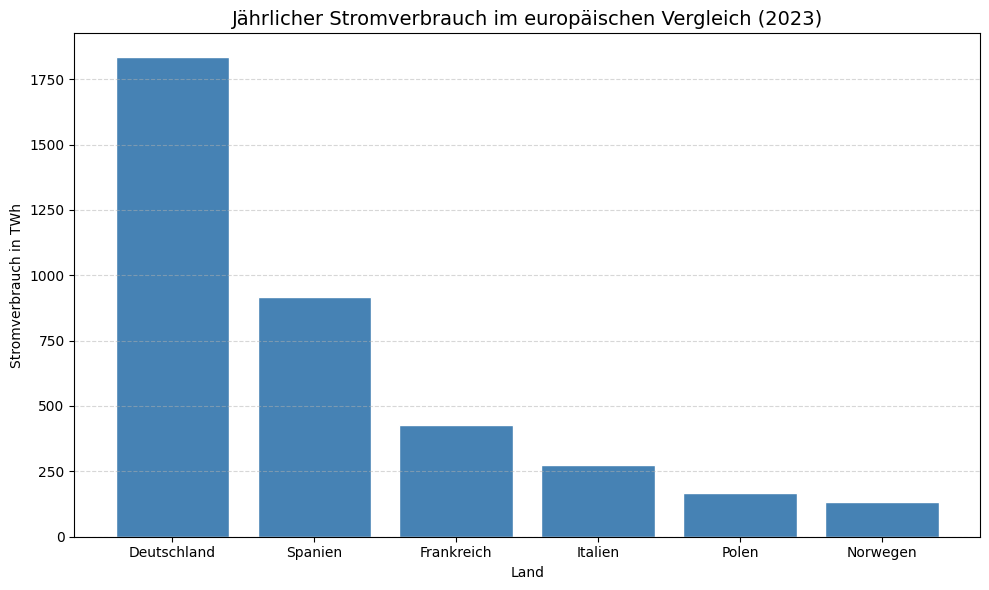

In [8]:
df = pd.DataFrame.from_dict(jahresdaten, orient="index", columns=["TWh"])
df = df.sort_values("TWh", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(df.index, df["TWh"], color="steelblue", edgecolor="white")

ax.set_title("Jährlicher Stromverbrauch im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Land")
ax.set_ylabel("Stromverbrauch in TWh")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("lastvergleich_2023.png")
plt.show()